# Shallow water model - visualization

In [1]:
# Imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils import plot_snapshots, plot_hovmoeller, dist_of_max_height, mean_period
from params import *

## Data

In [2]:
# Read the data
data_flat  = xr.open_dataset('../data/swm_flat.nc')
data_slope = xr.open_dataset('../data/swm_slope.nc')

## Plot both bathymetry case

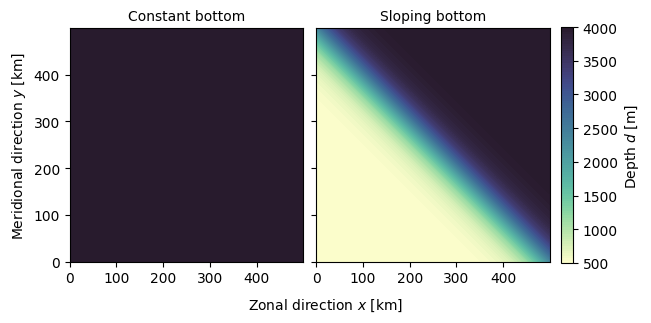

In [3]:
import cmocean
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, constrained_layout=True)

# Define meshgrid for contour plot
X, Y = np.meshgrid(data_flat.xpos*(dx/1e3), data_flat.ypos*(dy/1e3))

levels = np.linspace(500, 4000, 100)
cbar_ticks = np.arange(500, 4100, 500)

# Contour plot of depth
cp = ax[0].contourf(X, Y, data_flat.d,  levels=levels, cmap=cmocean.cm.deep)
cp = ax[1].contourf(X, Y, data_slope.d, levels=levels, cmap=cmocean.cm.deep)

# Axis labels
ax[0].set_ylabel(r'Meridional direction $y$ [km]')
fig.supxlabel(r'Zonal direction $x$ [km]', fontsize='medium', y=0.15)

# Titles
ax[0].set_title('Constant bottom', fontsize='medium')
ax[1].set_title('Sloping bottom', fontsize='medium')

ax[0].set_aspect(1)
ax[1].set_aspect(1)

# Color bar
cbar = fig.colorbar(cp,
    label=r'Depth $d$ [m]',
    ax=ax[1],
    shrink=0.5,
    ticks=cbar_ticks
    )

fig.savefig('plots/depth.png', bbox_inches='tight')
fig.savefig('plots/depth.pdf', bbox_inches='tight')
plt.show()

## Wave propagation (wave at selected time steps)

### a) Flat bottom

/home/green/code/fortran/sciprog-swm/python/utils.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


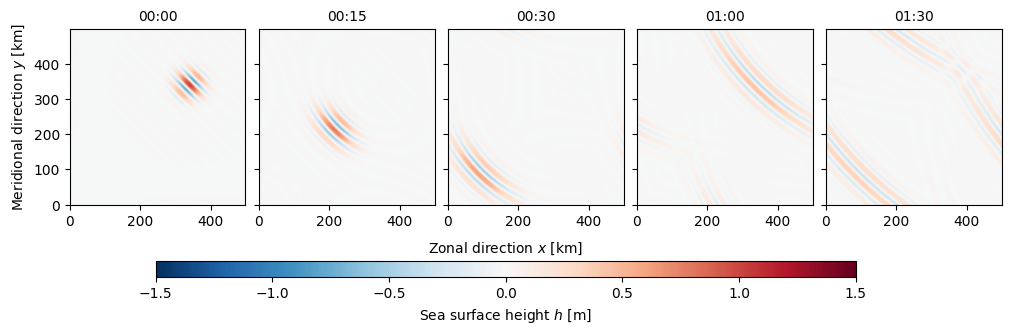

In [4]:
# Define which time steps to plot
# ts_to_plot = np.arange(0, 120, 20)
ts_to_plot = [0, 15, 30, 60, 90]

plot_snapshots(data_flat, ts_to_plot, 'plots/snapshots_flat.png', show_cbar=True)

### b) Sloping bottom

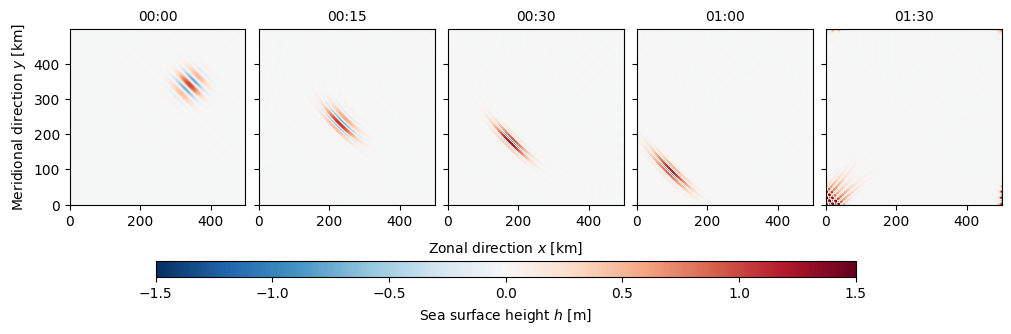

In [5]:
# Define which time steps to plot
# ts_to_plot = np.arange(0, 3, 1)
ts_to_plot = [0, 15, 30, 60, 90]

plot_snapshots(data_slope, ts_to_plot, 'plots/snapshots_slope.png')

## Hovmöller diagrams

### a) Flat bottom

/home/green/code/fortran/sciprog-swm/python/utils.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


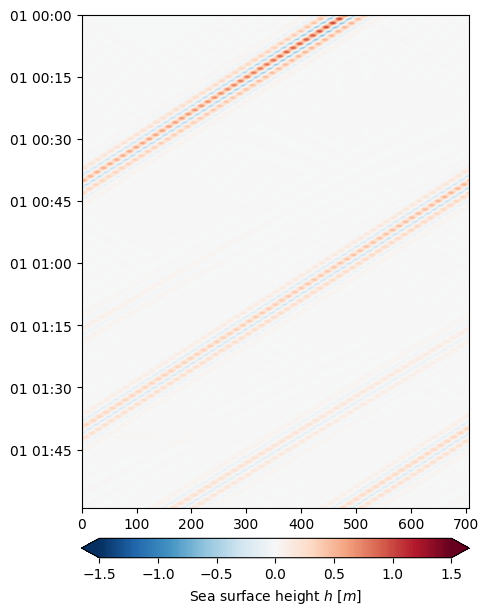

In [6]:
# Plot hovmöller diagram
plot_hovmoeller(data_flat, 'plots/hovmoeller-flat.png', time_formatted=True)

### b) Sloping bottom

/home/green/code/fortran/sciprog-swm/python/utils.py:112: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


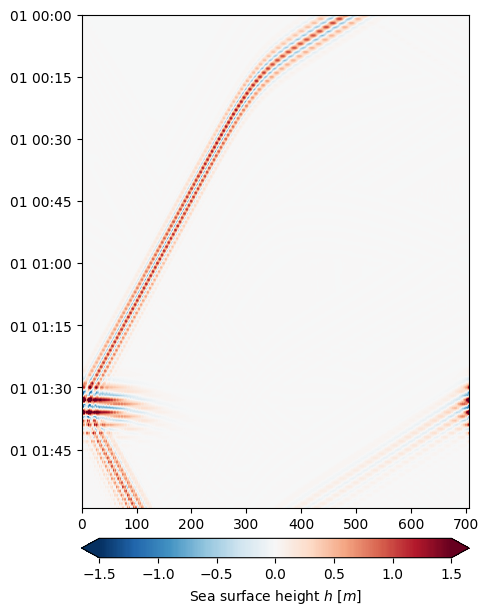

In [7]:
plot_hovmoeller(data_slope, 'plots/hovmoeller-slope.png', time_formatted=True)

## Typical velocity, wavelength and period of tsunami waves

$c = \sqrt{gh}$
- $c$: tsunami velocity [m/s]
- $g$: gravitational acceleration [m/s²]
- $h$: depth [m]

$\lambda = c T \quad \Leftrightarrow \quad c = \lambda/T \quad \Leftrightarrow \quad T = \lambda/c$
- $c$: velocity [km/h]
- $\lambda$: wavelength [km]
- $T$: period [h]


In [8]:
import pandas as pd

# Read tsunami data (ITIC, NOAA)
tsunami_data = pd.read_csv('tsunami-data.csv')
depth_exp = tsunami_data['h']
lambda_exp = tsunami_data['lambda']
c_exp = tsunami_data['c']

# Calculate typical tsunami period from data points
T_exp_h = lambda_exp / c_exp  # period [h]
T_exp_min = T_exp_h * 60 # period [min]

df = pd.DataFrame({
    "Depth [m]": depth_exp,
    "Velocity c [km/h]": c_exp,
    "Wavelength lambda [km]": lambda_exp,
    'Period T [min]': np.round(T_exp_min,1),
    })
df

,Depth [m],Velocity c [km/h],Wavelength lambda [km],Period T [min]
0,7000,943,282.0,17.9
1,4000,713,213.0,17.9
2,2000,504,151.0,18.0
3,200,159,48.0,18.1
4,50,79,23.0,17.5
5,10,36,10.6,17.7


## Simulated velocity

In [9]:
# Time steps where each wave hits western boundary
# (read from Hovmöller diagrams)
ts_boundary_hit_flat  = 40
ts_boundary_hit_slope = 90
ts_after_slope = 40
# ts_slope_hit = 20   # 

# Formatted time stamp when each wave hits western boundary
t_form_boundary_hit_flat  = t_form[ts_boundary_hit_flat]
t_form_boundary_hit_slope = t_form[ts_boundary_hit_slope]

# Get starting distance of each wave
start_dist_flat  = dist_of_max_height(data_flat,  ts=0)
start_dist_slope = dist_of_max_height(data_slope, ts=0)

# Distance travelled
dist_traveled_flat  = dist_of_max_height(data_flat,  ts=0)
dist_traveled_slope = dist_of_max_height(data_slope, ts=ts_after_slope) - dist_of_max_height(data_slope, ts=ts_boundary_hit_slope)

# Time
t_slope = t_min[ts_boundary_hit_slope] - t_min[ts_after_slope] # in min
t_flat  = t_min[ts_boundary_hit_flat] # in min

# Velocity
c_4000 = dist_traveled_flat/t_min[ts_boundary_hit_flat] * 60 # km/h
c_500  = dist_traveled_slope/(t_min[ts_boundary_hit_slope] - t_min[ts_after_slope]) * 60 # km/h

print(f'velocity over 4000 m depth: {c_4000:.2f} km/h')
print(f'velocity over  500 m depth: {c_500:.2f} km/h')

# Print starting distance (should be same value)
print(f'Wave over flat bottom starts at {start_dist_flat:.0f} km distance.')
print(f'Wave over sloping bottom starts at {start_dist_slope:.0f} km distance.')# 

# Print boundary hits
print(f'Wave hits western boundary after {ts_boundary_hit_flat} time steps, i.e. at {t_form_boundary_hit_flat}')
print(f'Wave hits western boundary after {ts_boundary_hit_slope} time steps, i.e. at {t_form_boundary_hit_slope}')

velocity over 4000 m depth: 721.25 km/h
velocity over  500 m depth: 232.50 km/h
Wave over flat bottom starts at 481 km distance.
Wave over sloping bottom starts at 481 km distance.
Wave hits western boundary after 40 time steps, i.e. at 2026-01-01T00:40
Wave hits western boundary after 90 time steps, i.e. at 2026-01-01T01:30


In [10]:
# dist_traveled_flat, t_flat, t_flat/60, c_4000
dist_traveled_slope, t_slope, t_slope/60, c_500

(np.float64(193.74725804511402),
 np.float64(50.0),
 np.float64(0.8333333333333334),
 np.float64(232.49670965413682))

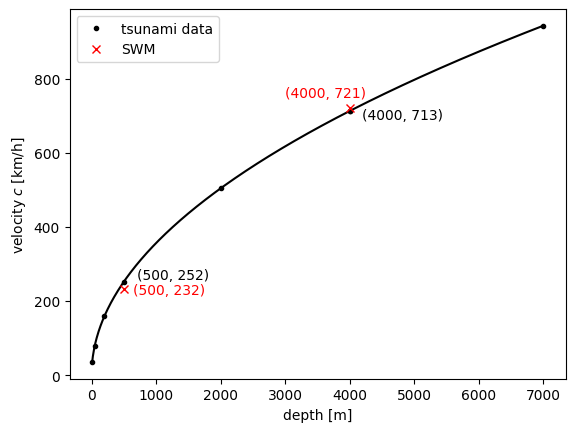

In [11]:
# Velocity as c = sqrt(g*depth)
depth_lin = np.arange(10, 7000, 10) # m
c_lin_ms  = np.sqrt(g * depth_lin) # m/s
c_lin_kmh = c_lin_ms / 1e3 * 60 * 60    # km/h

# Select expected velocities
c_4000_exp = c_exp[1]
c_500_exp  = c_lin_kmh[49]

# Plot data points
plt.plot(depth_exp, c_exp, '.', c='k', label='tsunami data')
# Plot computed velocities
plt.plot(depth_lin, c_lin_kmh, '-', c='k')#, label='typical tsunami velocities')

# Highlight expected and simulated velocities
plt.plot(4000, c_4000_exp, '.', c='k')
plt.plot(500,  c_500_exp,  '.', c='k')
plt.plot(4000, c_4000,    'x', c='red')
plt.plot(500,  c_500,     'x', c='red', label='SWM')

# Annotate expected and simulated velocities
plt.annotate(f'(4000, {c_4000_exp})', (4200, 690))
plt.annotate(f'(4000, {round(c_4000)})', (3000, 750), c='red')
plt.annotate(f'(500, {round(c_500_exp)})', (700, 260))
plt.annotate(f'(500, {round(c_500)})', (650, 220), c='red')

# plt.title('Typical Tsunami velocities')
plt.xlabel('depth [m]')
plt.ylabel('velocity $c$ [km/h]')
plt.legend()

plt.savefig('plots/expected-vel.pdf')
plt.savefig('plots/expected-vel.png')
plt.show()

## Simulated wave period

In [12]:
# Average typical period [min]
T_exp_min = np.mean(T_exp_min)
# test = mean_period(data_flat, np.arange(0,120,1))

# Expected period in time steps
T_ts = round(T_exp_min/(dt/60))

print(f'Expected period: T = {T_exp_min:.1f} min, i.e. ~{T_ts} time steps')

# Actual period
T_ts = 3
T = T_ts*(dt/60)
print(f'Actual period: T = {T_ts} time steps, i.e. {T} minutes')


Expected period: T = 17.8 min, i.e. ~18 time steps
Actual period: T = 3 time steps, i.e. 3.0 minutes


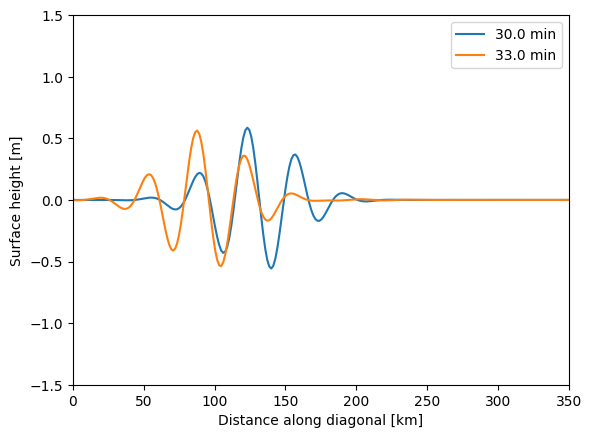

In [13]:
data = data_flat

# Specify which time step to plot
ts = 30

# Select heights along diagonal
h_diag = data.h.where(data.xpos == data.ypos).stack(diag=('xpos', 'ypos')).dropna('diag')

# Plot both wave trains to verify wave period
plt.plot(diag_dist_km, h_diag.isel(time=ts), label=f'{ts*(dt/60)} min')
# plt.plot(diag_dist_km, h_diag.isel(time=ts+offset), label=f'{(ts+offset)*dt} min')
plt.plot(diag_dist_km, h_diag.isel(time=ts+T_ts), label=f'{(ts+T_ts)*(dt/60)} min')

plt.xlim(0, 350)
plt.ylim(-1.5, 1.5)
# plt.title(f'4000 m depth')
plt.xlabel('Distance along diagonal [km]')
plt.ylabel('Surface height [m]')
plt.legend()

plt.savefig('plots/period4000.png', bbox_inches='tight')
plt.savefig('plots/period4000.pdf', bbox_inches='tight')
plt.show()

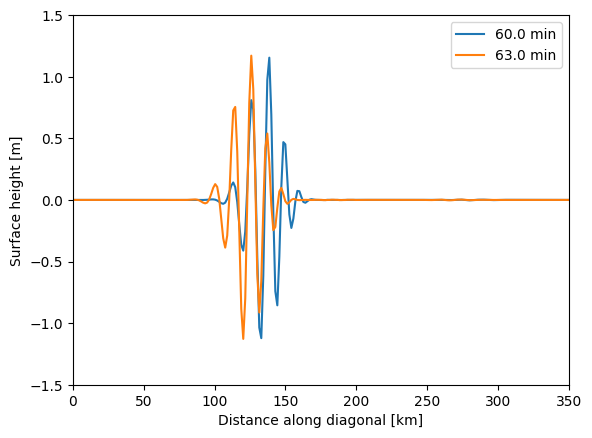

In [14]:
data = data_slope

# Specify which time step to plot
ts = 60

# Select heights along diagonal
h_diag = data.h.where(data.xpos == data.ypos).stack(diag=('xpos', 'ypos')).dropna('diag')

# Plot both wave trains to verify wave period
plt.plot(diag_dist_km, h_diag.isel(time=ts), label=f'{ts*(dt/60)} min')
# plt.plot(diag_dist_km, h_diag.isel(time=ts+offset), label=f'{(ts+offset)*dt} min')
plt.plot(diag_dist_km, h_diag.isel(time=ts+T_ts), label=f'{(ts+T_ts)*(dt/60)} min')

plt.xlim(0, 350)
plt.ylim(-1.5, 1.5)
# plt.title(f'500 m depth')
plt.xlabel('Distance along diagonal [km]')
plt.ylabel('Surface height [m]')
plt.legend()

plt.savefig('plots/period500.png', bbox_inches='tight')
plt.savefig('plots/period500.pdf', bbox_inches='tight')
plt.show()

## Simulated wavelength

$\lambda = c T \quad \Leftrightarrow \quad c = \lambda/T \quad \Leftrightarrow \quad T = \lambda/c$

In [15]:
# Calculate wavelength at 4000 m and 500 m depth from velocity and period
T_min = T_ts*(dt/60)         # period in min
T_h = T_min / 60        # period in h
lambda_4000 = c_4000 * T_h   # in km
lambda_500  = c_500  * T_h   # in km

# Print results
print(f"Wavelength at 4000 m ≈ {lambda_4000:.1f} km ")
print(f"Wavelength at  500 m ≈ {lambda_500:.1f} km ")

Wavelength at 4000 m ≈ 36.1 km 
Wavelength at  500 m ≈ 11.6 km 


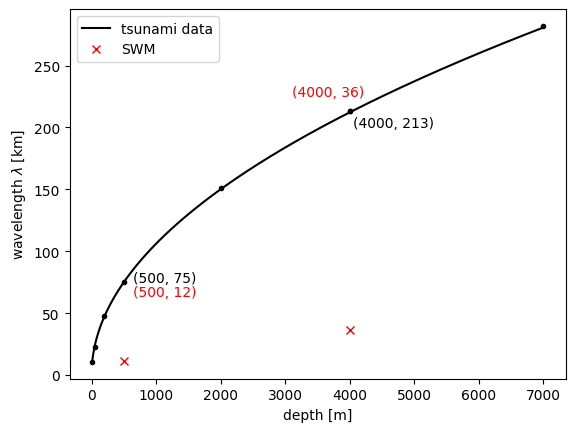

In [16]:
# Plot data points
plt.plot(depth_exp, lambda_exp, '.', c='k', lw=1)

# Calculate as lambda = c*T
depths_lin = np.arange(10, 7000, 10) # m
T_s      = T_exp_min * 60       # period in s
lambda_lin_m  = c_lin_ms * T_s   # wavelength in m
lambda_lin_km = lambda_lin_m / 1e3    # wavelength in km

# Select expected values from data/calculation
lambda_500_exp  = lambda_lin_km[49]
lambda_4000_exp = lambda_exp[1]

# Plot calculated wavelengths
plt.plot(depths_lin, lambda_lin_km, '-', c='k', label='tsunami data')

# Highlight expected values
plt.plot(4000, lambda_4000_exp, '.', c='k')
plt.plot(500,  lambda_500_exp, '.', c='k')

# Highlight simulated values
plt.plot(4000, lambda_4000, 'x', c='red', label='SWM')
plt.plot(500,  lambda_500, 'x', c='red')

# Annotate expected values
plt.annotate(f'(4000, {lambda_4000_exp:.0f})', (4050, 200))
plt.annotate(f'(500, {lambda_500_exp:.0f})',   (650, 75))

# Annotate simulated values
plt.annotate(f'(4000, {lambda_4000:.0f})', (3100, 225), c='red')
plt.annotate(f'(500, {lambda_500:.0f})',  (650, 64),  c='red')

# Figure settings
plt.xlabel(r'depth [m]')
plt.ylabel(r'wavelength $\lambda$ [km]')
plt.legend()

# Save and show
plt.savefig('plots/expected-wavelength.pdf')
plt.savefig('plots/expected-wavelength.png')
plt.show()